<a href="https://colab.research.google.com/github/omermumtaz05/animals-10-r18/blob/main/animals_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from PIL import Image
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import numpy as np

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from collections import Counter
from torch.utils.data import random_split


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/animals_10/', exist_ok=True)

Mounted at /content/drive


In [ ]:
os.environ['KAGGLE_USERNAME'] = ''
os.environ['KAGGLE_KEY'] = ''


In [ ]:
#Dataset is called animals10 from alessiocorrado99 on Kaggle

In [ ]:
training_dataset_path = './raw-img'

print(os.getcwd())                    # your current working directory

print(os.listdir('./raw-img')) # check the 6 class folders inside 'Images'

/content
['scoiattolo', 'farfalla', 'gallina', 'elefante', 'cavallo', 'gatto', 'mucca', 'cane', 'pecora', 'ragno']


In [ ]:
base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

])

aug_transform = transforms.Compose([ #augmented
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(224, padding = 4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

In [ ]:
from torch.utils.data import Dataset

In [ ]:
full_dataset = datasets.ImageFolder(root=training_dataset_path)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_indices, test_indices = random_split(range(len(full_dataset)), [train_size, test_size])


train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=training_dataset_path, transform=aug_transform),
    train_indices
)

test_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=training_dataset_path, transform=base_transform),
    test_indices
)

In [ ]:
train_dataset.dataset.transform = aug_transform
test_dataset.dataset.transform = base_transform

In [ ]:
test_dataset

In [ ]:
from collections import Counter

targets = [label for _, label in train_dataset]
class_counts = Counter(targets)





In [ ]:
class_counts

Counter({4: 2489,
         6: 1498,
         8: 3853,
         7: 1482,
         9: 1511,
         1: 2091,
         5: 1323,
         0: 3847,
         2: 1157,
         3: 1692})

In [ ]:


class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in targets]


In [ ]:
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(targets),
    replacement=True
)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 32, sampler = sampler, num_workers = 4, pin_memory = True)

In [ ]:
train_dataset.dataset.transform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomCrop(size=(224, 224), padding=4)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
)

In [ ]:
test_dataset.dataset.transform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)

In [ ]:

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
import torch

# Simulate one full pass through the sampler
sampled_indices = list(sampler)

# Get labels for those sampled indices
sampled_labels = [train_dataset[i][1] for i in sampled_indices]

# Count how many times each class was sampled
sampled_class_counts = Counter(sampled_labels)

# Print or inspect counts
for cls in sorted(sampled_class_counts):
    print(f"Class {cls}: {sampled_class_counts[cls]} samples")


KeyboardInterrupt: 

In [ ]:
sampled_class_counts

Counter({4: 2106,
         3: 2010,
         9: 2118,
         0: 2097,
         6: 2132,
         5: 2051,
         8: 2116,
         2: 2124,
         1: 2091,
         7: 2098})

In [ ]:
train_loader

In [ ]:
os.listdir(training_dataset_path)

['scoiattolo',
 'farfalla',
 'gallina',
 'elefante',
 'cavallo',
 'gatto',
 'mucca',
 'cane',
 'pecora',
 'ragno']

In [ ]:
test_loader

In [ ]:

resnet18 = torchvision.models.resnet18()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = resnet18.to(device)
#X_batch, y_batch = X_batch.to(device), y_batch.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.parameters(), lr = 0.001)

In [ ]:


gpu_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if gpu_available else "No GPU detected"

print(f"GPU available: {gpu_available}")
print(f"GPU name: {gpu_name}")

GPU available: True
GPU name: NVIDIA A100-SXM4-40GB


In [ ]:
from sklearn.metrics import f1_score

num_classes = 10
epochs = 30

best_f1 = 0.0

train_losses = []
test_losses = []

train_total_corr = []
test_total_corr = []

f1_score_per_epoch = []

train_correct_per_class = [0] * num_classes
test_correct_per_class = [0] * num_classes

train_count_per_class = [0] * num_classes
test_count_per_class = [0] * num_classes

for i in range(epochs):

    trn_corr = 0
    tst_corr = 0

    train_loss_per_epoch = 0
    test_loss_per_epoch = 0

    train_b_count = 0
    test_b_count = 0

    avg_train_loss_per_epoch = 0
    avg_test_loss_per_epoch = 0


    for b,(X_train, y_train) in enumerate(train_loader):
        b += 1
        train_b_count += 1

        X_train, y_train = X_train.to(device), y_train.to(device)
        y_pred = resnet18(X_train)
        loss = criterion(y_pred, y_train)
        train_loss_per_epoch += loss.item()


        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        for class_label, pred in zip(y_train, predicted):
            class_label = class_label.item()
            pred = pred.item()

            train_count_per_class[class_label] += 1
            if(class_label == pred):
                train_correct_per_class[class_label] += 1


        #update params
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%100 == 0:
            print(f'Epoch: {i}, Batch: {b}, Loss: {loss.item()}')

    avg_train_loss_per_epoch = train_loss_per_epoch/train_b_count

    train_losses.append(avg_train_loss_per_epoch)
    train_total_corr.append(trn_corr.item())


    with torch.no_grad():
        all_test_labels = []
        all_test_preds = []


        for b,(X_test, y_test) in enumerate(test_loader):
            test_b_count += 1
            X_test, y_test = X_test.to(device), y_test.to(device)
            y_val = resnet18(X_test)
            predicted = torch.max(y_val.data, 1)[1]
            tst_corr += (predicted == y_test).sum()

            loss = criterion(y_val, y_test)
            test_loss_per_epoch += loss.item()

            # Append all labels and predictions to lists
            all_test_labels.extend(y_test.cpu().numpy())
            all_test_preds.extend(predicted.cpu().numpy())

            for test_label, pred in zip(y_test, predicted):
                test_label = test_label.item()
                pred = pred.item()

                if(test_label == pred):
                    test_correct_per_class[test_label] += 1

                test_count_per_class[test_label] += 1


    avg_test_loss_per_epoch = test_loss_per_epoch/test_b_count
    test_losses.append(avg_test_loss_per_epoch)
    test_total_corr.append(tst_corr.item())

    # Example: print F1 score for test set
    f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
    f1_score_per_epoch.append(f1)

    if f1 > best_f1:
      best_f1 = f1
      torch.save(resnet18.state_dict(), '/content/drive/MyDrive/animals_10/best_model.pt')

    print(f"Epoch {i} Test F1 Score: {f1:.4f}")


Epoch: 0, Batch: 100, Loss: 2.3561649322509766
Epoch: 0, Batch: 200, Loss: 1.951555848121643
Epoch: 0, Batch: 300, Loss: 1.9261505603790283
Epoch: 0, Batch: 400, Loss: 1.774782657623291
Epoch: 0, Batch: 500, Loss: 2.122448444366455
Epoch: 0, Batch: 600, Loss: 1.9410645961761475
Epoch 0 Test F1 Score: 0.2885
Epoch: 1, Batch: 100, Loss: 1.5074121952056885
Epoch: 1, Batch: 200, Loss: 1.4897034168243408
Epoch: 1, Batch: 300, Loss: 1.4792675971984863
Epoch: 1, Batch: 400, Loss: 1.5387187004089355
Epoch: 1, Batch: 500, Loss: 1.2668569087982178
Epoch: 1, Batch: 600, Loss: 1.340029001235962
Epoch 1 Test F1 Score: 0.4290
Epoch: 2, Batch: 100, Loss: 1.2276265621185303
Epoch: 2, Batch: 200, Loss: 1.5269229412078857
Epoch: 2, Batch: 300, Loss: 1.1970959901809692
Epoch: 2, Batch: 400, Loss: 1.215057611465454
Epoch: 2, Batch: 500, Loss: 1.2838597297668457
Epoch: 2, Batch: 600, Loss: 1.2511407136917114
Epoch 2 Test F1 Score: 0.4524
Epoch: 3, Batch: 100, Loss: 1.4917454719543457
Epoch: 3, Batch: 200, 

In [ ]:
best_f1

0.7786459820703185

In [ ]:
import matplotlib.pyplot as plt

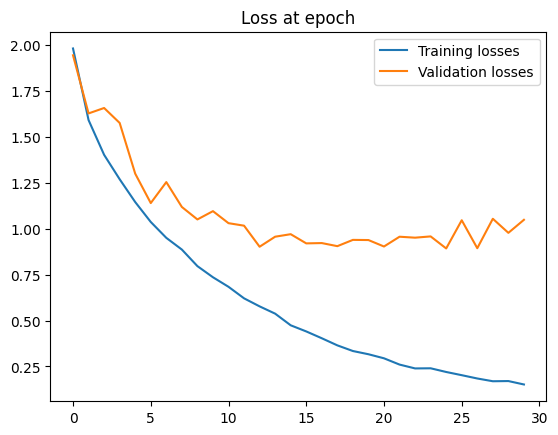

In [ ]:
#train_losses = [tl.item() for tl in train_losses]
#test_losses = [ts.item() for ts in test_losses]
train_losses = [tl.item() if isinstance(tl, torch.Tensor) else tl for tl in train_losses]
test_losses = [ts.cpu().item() if isinstance(ts, torch.Tensor) else ts for ts in test_losses]
plt.plot(train_losses, label = "Training losses")
plt.plot(test_losses, label = 'Validation losses')
plt.title("Loss at epoch")
plt.legend()


In [ ]:
test_losses

[1.944531873231981,
 1.6279120365294015,
 1.6574352779766408,
 1.5760375101391861,
 1.2997841427965862,
 1.1395856741724946,
 1.2538789488920352,
 1.118386835223291,
 1.0504700606916009,
 1.095606490242772,
 1.0301214345708125,
 1.0165048659574696,
 0.9018698729938124,
 0.9564690012030486,
 0.9701650728721444,
 0.9201007929698723,
 0.9217808156660418,
 0.9049763870311947,
 0.9391265148978408,
 0.9382567646481642,
 0.9031220582745424,
 0.9563637059636232,
 0.9511438142962572,
 0.9580658739659844,
 0.8925139190765415,
 1.0460918039628646,
 0.8937989629623366,
 1.0541305714627591,
 0.9774855813920135,
 1.048469106962041]

In [ ]:
len(test_dataset)

5236

In [ ]:
tst_corr.item()

3932

In [ ]:
percentage = (tst_corr.item()/len(test_dataset))*100
print(f"Percentage of correct: {percentage:.2f}%")

Percentage of correct: 75.10%


In [ ]:
for i in range(num_classes):
  accuracy_per_class_train = (train_correct_per_class[i]/train_count_per_class[i]) * 100

  print(f"Training accuracy in class {i} = {accuracy_per_class_train:.2f}")

Training accuracy in class 0 = 63.73
Training accuracy in class 1 = 77.07
Training accuracy in class 2 = 84.77
Training accuracy in class 3 = 84.47
Training accuracy in class 4 = 76.91
Training accuracy in class 5 = 81.01
Training accuracy in class 6 = 78.49
Training accuracy in class 7 = 79.67
Training accuracy in class 8 = 81.13
Training accuracy in class 9 = 77.63


In [ ]:
for i in range(num_classes):
  accuracy_per_class_test = (test_correct_per_class[i]/test_count_per_class[i]) * 100
  print(f"Testing accuracy in class {i} = {accuracy_per_class_test:.2f}%")

Testing accuracy in class 0 = 55.90%
Testing accuracy in class 1 = 71.28%
Testing accuracy in class 2 = 73.24%
Testing accuracy in class 3 = 77.87%
Testing accuracy in class 4 = 68.51%
Testing accuracy in class 5 = 74.60%
Testing accuracy in class 6 = 65.23%
Testing accuracy in class 7 = 61.82%
Testing accuracy in class 8 = 67.33%
Testing accuracy in class 9 = 66.66%


In [ ]:
for i in range(30):
  print(f"F1 score in epoch {i} is {f1_score_per_epoch[i]}")

F1 score in epoch 0 is 0.28852053798231947
F1 score in epoch 1 is 0.4290280200347398
F1 score in epoch 2 is 0.45242148998380205
F1 score in epoch 3 is 0.4431172782502067
F1 score in epoch 4 is 0.5669056555197746
F1 score in epoch 5 is 0.6287815904878493
F1 score in epoch 6 is 0.5958460892351283
F1 score in epoch 7 is 0.6281674877952477
F1 score in epoch 8 is 0.6536271806194633
F1 score in epoch 9 is 0.6463369617725649
F1 score in epoch 10 is 0.6669803989630625
F1 score in epoch 11 is 0.6821366409793296
F1 score in epoch 12 is 0.7226213401711158
F1 score in epoch 13 is 0.7097919840096836
F1 score in epoch 14 is 0.7083726251896717
F1 score in epoch 15 is 0.7288610096831476
F1 score in epoch 16 is 0.7451521244593173
F1 score in epoch 17 is 0.7445955131804218
F1 score in epoch 18 is 0.7393876829082575
F1 score in epoch 19 is 0.7388409036440556
F1 score in epoch 20 is 0.749944872557896
F1 score in epoch 21 is 0.7427625637670706
F1 score in epoch 22 is 0.7491821354586904
F1 score in epoch 23

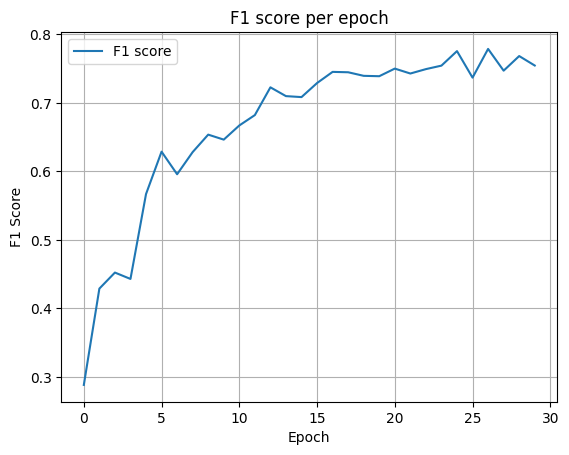

In [ ]:
#train_losses = [tl.item() for tl in train_losses]
#test_losses = [ts.item() for ts in test_losses]

f1_score_graph = [tl.item() if isinstance(tl, torch.Tensor) else tl for tl in f1_score_per_epoch]
plt.plot(f1_score_per_epoch, label = "F1 score")
plt.title("F1 score per epoch")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()


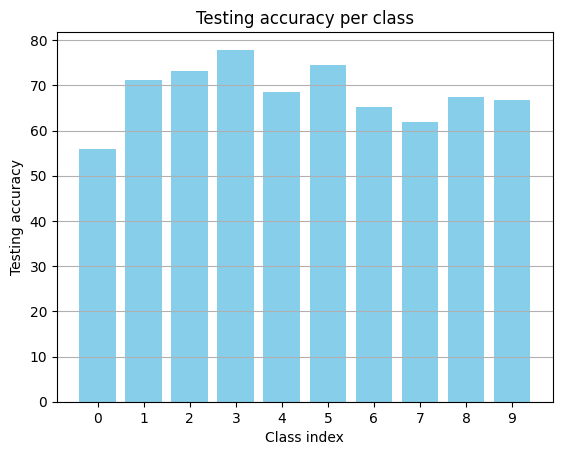

In [ ]:

test_accuracy_per_class = []

for i in range(num_classes):
  test_accuracy_per_class.append((test_correct_per_class[i]/test_count_per_class[i]) * 100)


test_accuracy_graph = [tl.item() if isinstance(tl, torch.Tensor) else tl for tl in test_accuracy_per_class]

plt.bar(range(num_classes), test_accuracy_graph, color='skyblue')
plt.title("Testing accuracy per class")
plt.xlabel("Class index")
plt.ylabel("Testing accuracy")
plt.xticks(range(num_classes))  # show all epoch numbers
plt.grid(axis='y')
plt.show()

In [ ]:
# Load best model
resnet18.load_state_dict(torch.load('/content/drive/MyDrive/animals_10/best_model.pt'))
resnet18.eval()

num_classes = 10
correct_per_class = [0] * num_classes
count_per_class = [0] * num_classes
total_correct = 0
total_samples = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        outputs = resnet18(X_test)
        predicted = torch.max(outputs, 1)[1]

        total_correct += (predicted == y_test).sum().item()
        total_samples += y_test.size(0)

        for label, pred in zip(y_test, predicted):
            count_per_class[label.item()] += 1
            if label.item() == pred.item():
                correct_per_class[label.item()] += 1

# Results
print(f"overall accuracy: {100 * total_correct / total_samples:.2f}%")
print(f"\nper class accuracy:")
for c in range(num_classes):
    acc = 100 * correct_per_class[c] / count_per_class[c]
    print(f"Class {c}: {acc:.2f}%")

overall accuracy: 79.37%

per class accuracy:
Class 0: 78.74%
Class 1: 83.65%
Class 2: 76.82%
Class 3: 85.95%
Class 4: 80.95%
Class 5: 81.16%
Class 6: 80.98%
Class 7: 58.58%
Class 8: 80.48%
Class 9: 79.77%


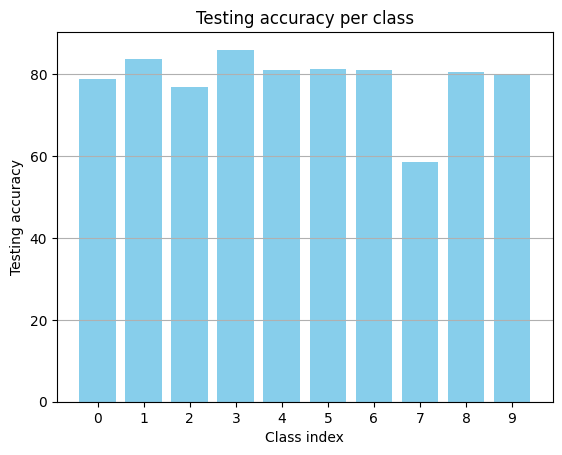

In [ ]:

best_test_accuracy_per_class = []

for i in range(num_classes):
  best_test_accuracy_per_class.append((correct_per_class[i]/count_per_class[i]) * 100)


best_test_accuracy_graph = [tl.item() if isinstance(tl, torch.Tensor) else tl for tl in best_test_accuracy_per_class]

plt.bar(range(num_classes), best_test_accuracy_graph, color='skyblue')
plt.title("Testing accuracy per class")
plt.xlabel("Class index")
plt.ylabel("Testing accuracy")
plt.xticks(range(num_classes))  # show all epoch numbers
plt.grid(axis='y')
plt.show()